In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.gridspec import GridSpec
import matplotlib

import sys

sys.path.append("../src")

import jax
import jax.numpy as jnp

import netket as nk
import numpy as np

from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
from netket.experimental.dynamics import RK45
from callbacks import (
    get_acceptance_rate_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
)
from logger import Logger

from schmitt_tdvp_bridge import TDVPSchmittBridge
from schmitt_tdvp import TDVPSchmitt

import argparse
import numpy as np

from gaussian_state import GaussianState
from tfim_exact_majorana import run_ed


W0218 20:00:26.475402 1941183 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0218 20:00:26.478151 1941037 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can disable these tips by setting export NETKET_NO_TIPS=1 in your .bashrc.

In [ ]:
fields_to_track = (
        ("t", "values"),
        ("dt", "values"),
        ("Generator", "Mean"),
        ("Generator", "Variance"),
        ("parity", "Mean"),
        ("parity", "Variance"),
        ("r_squared", "values"),
        # Umbrella/bridge monitoring fields
        ("ess_bridge", "values"),
        ("snr_min", "values"),
        ("snr_10p", "values"),
        ("snr_med", "values"),
        ("snrF_min", "values"),
        ("snrF_med", "values"),
        ("q_bridge", "values"),
        # Per-step SNRs from OVar
        ("snr", "values"),
        ("snr_F", "values"),
        ("acceptance_rate", "values"),
    )

def main(N, n_samples_tvmc, driver_type, q, h, chunk_size):
    print(N, n_samples_tvmc, driver_type, q, h)
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

    def get_model(dtype):
        return GaussianState(param_dtype=dtype)

    def get_vstates(n_samples, sampling_dtype=jnp.float64):
        seed = 300
        model = get_model(jnp.float64)
        sampler = nk.sampler.MetropolisSampler(
            hilbert, LocalDoubleFlipRule(), n_chains=n_samples
        )
        vstate = nk.vqs.MCState(
            sampler=sampler,
            model=model,
            n_samples=n_samples,
            seed=seed,
            sampler_seed=seed,
            n_discard_per_chain=0,
            chunk_size=chunk_size,
        )
        model_sampling = get_model(sampling_dtype)
        sampler_sampling = nk.sampler.MetropolisSampler(
            hilbert, LocalDoubleFlipRule(), n_chains=n_samples, dtype=sampling_dtype
        )
        vstate_sampling = nk.vqs.MCState(
            sampler=sampler_sampling,
            model=model_sampling,
            n_samples=n_samples,
            seed=seed,
            sampler_seed=seed,
            n_discard_per_chain=0,
        )

        return vstate, vstate_sampling

    # Check energy and parity
    sigma_z = nk.operator.PauliStringsJax(hilbert, "Z" * N, 1.0)
    graph = nk.graph.Chain(N, pbc=True)
    Hxx = sum([sigmax(hilbert, i) @ sigmax(hilbert, j) for i, j in graph.edges()])
    stab_hamiltonian = -Hxx - sigma_z
    # Hamiltonian
    hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=-h, J=1.0)

    def measure_parity(step, log, driver):
        log["parity"] = driver.state.expect(sigma_z)
        return True

    T = 2.0
    save_times = np.linspace(0.0, T, 40)
    if driver_type == "bridge":
        exp_name = f"bridge_{n_samples_tvmc}_{q:1.2f}"
    elif driver_type == "vanilla":
        exp_name = f"vanilla_{n_samples_tvmc}"
    else:
        raise NotImplementedError
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_{N}_parity_h_{h:1.3f}/PFAFF/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
        else:
            t0 = logger["t"]["values"][-1]
            dt = logger["dt"]["values"][-1]
    else:
        t0 = 0.0
        dt = 1e-5
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    vstate, vstate_sampling = get_vstates(n_samples_tvmc, jnp.float32)
    parity_expect = vstate.expect(sigma_z)
    stab_energy = vstate.expect(stab_hamiltonian)
    print(f"parity: {parity_expect}")
    print(f"parity: {stab_energy}")
    print(f"Number of parameters: {vstate.n_parameters}")
    # Thermalize
    for i in range(1):
        vstate.sample()
        vstate_sampling.sample()

    callbacks = []
    callbacks.append(measure_parity)
    acceptance_rate_callback = get_acceptance_rate_callback()
    callbacks.append(acceptance_rate_callback)
    if driver_type == "bridge":
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    elif driver_type == "vanilla":
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(parameter_save_callback)

    integrator = RK45(dt, adaptive=True, rtol=1e-4, dt_limits=(1e-5, 1e-2))
    tvmc_kwargs = {}

    if driver_type == "bridge":
        dynamics = TDVPSchmittBridge(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            q=q,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            sampling_state=vstate_sampling,
            distributed_eigh=True,
            **tvmc_kwargs,
        )
    elif driver_type == "vanilla":
        dynamics = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        raise NotImplementedError

    dynamics.run(
        T,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

Restored q:0.50 True
Restored q:0.50 True


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_1941037/3167565100.py:43: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z[0].plot(
/tmp/ipykernel_1941037/3167565100.py:70: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z[1].plot(
/tmp/ipykernel_1941037/3167565100.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be 

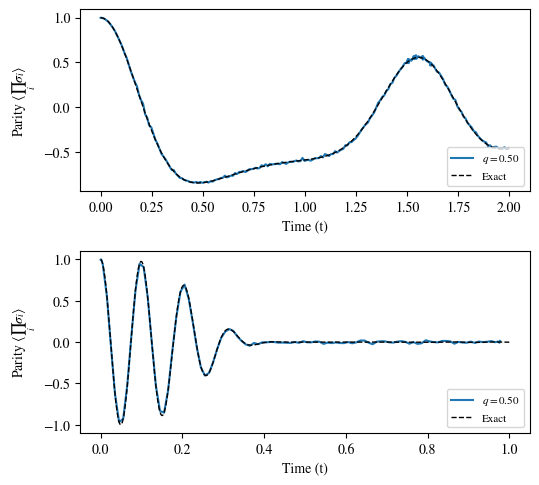

In [28]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
n_samples_list = [2**i for i in range(10, 14)]
N = 32
q = 0.5
n_samples_to_plot = 2**13

# Create figure with custom GridSpec for bottom row spacing
fig = plt.figure(figsize=(5.8, 5.5))
gs = GridSpec(2, 1, figure=fig, wspace=0.45, hspace=0.33)
ax_z = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]
# ax_dt = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

# Vanilla parity
# exp_name = f"bridge_{n_samples_to_plot}_{q:1.2f}"
# save_path = (
#     f"./data/TFIM_{N}_parity/PFAFF/hotstart_vanilla_{n_samples_to_plot}/"
# )
# color_t005 = "tab:cyan"

# logger = Logger(path=save_path, fields=fields_to_track)
# print(f"Restored q:{q:1.2f}", logger.restore())
# ax_z.plot(
#     logger.data["t"]["values"],
#     logger.data["parity"]["Mean"],
#     label=f"Plain ($t_0=$0.05)",
#     color=color_t005,
#     zorder=0,
# )
h = 1 / 8
save_path = (
    f"./data/TFIM_{N}_parity_h_{h:1.3f}/PFAFF/bridge_{n_samples_to_plot}_{q:1.2f}/"
)
logger = Logger(path=save_path, fields=fields_to_track)
print(f"Restored q:{q:1.2f}", logger.restore())
times_exact, parity_exact = run_ed(N, h=h, J=1.0, T=2.0)
ax_z[0].plot(
    logger.data["t"]["values"],
    logger.data["parity"]["Mean"],
    label=f"$q = ${q:1.2f}",
    zorder=0,
)
ax_z[0].plot(
    times_exact,
    np.real(parity_exact),
    "k-",
    linewidth=1,
    label="Exact",
    zorder=1,
    linestyle="dashed",
)
x_vals_bridge = logger.data["t"]["values"]
# if logger.data["dt"]["values"]:
#     ax_dt[0].plot(x_vals_bridge, logger.data["dt"]["values"], label="Bridge")
# OTHER h
h = 1.0
save_path = (
    f"./data/TFIM_{N}_parity_h_{h:1.3f}/PFAFF/bridge_{n_samples_to_plot}_{q:1.2f}/"
)
logger = Logger(path=save_path, fields=fields_to_track)
print(f"Restored q:{q:1.2f}", logger.restore())

times_exact, parity_exact = run_ed(N, h=h, J=1.0, T=2.0)
ax_z[1].plot(
    logger.data["t"]["values"][:110],
    logger.data["parity"]["Mean"][:110],
    label=f"$q = ${q:1.2f}",
    zorder=0,
)
ax_z[1].plot(
    times_exact[:len(times_exact)//2],
    np.real(parity_exact)[:len(times_exact)//2],
    "k-",
    linewidth=1,
    label="Exact",
    zorder=1,
    linestyle="dashed",
)

x_vals_bridge = logger.data["t"]["values"]
# if logger.data["dt"]["values"]:
#     ax_dt[1].plot(x_vals_bridge, logger.data["dt"]["values"], label="Bridge")
# # Vanilla
# logger_vanilla = Logger(path=f"./data/TFIM_{N}_parity/PFAFF/vanilla_{n_samples_to_plot}/", fields=fields_to_track)
# logger_vanilla.restore()
# x_vals_vanilla = logger_vanilla.data["t"]["values"]
# if logger_vanilla.data["dt"]["values"]:
#     ax_dt.plot(x_vals_vanilla, logger_vanilla.data["dt"]["values"], label="Plain",color=color_t005)
for ax in ax_z:
    ax.set_xlabel("Time (t)")
    ax.set_ylabel(r"Parity $\langle\prod_i \sigma_i\rangle$")
    ax.legend(loc="lower right", fontsize=8)

# for ax in ax_dt:
#     ax.set_xlabel("Time (t)")
#     ax.set_ylabel("dt")
#     ax.set_yscale("log")
#     ax.set_ylim([1e-5, 5e-2])
#     ax.legend(loc="best", fontsize=7)

# r_squared error (bottom right)
# Bridge
# r_sq_bridge = logger_bridge.data["r_squared"]["values"]
# if r_sq_bridge:
#     r_sq_arr_bridge = np.array(r_sq_bridge, dtype=float)
#     ax_rsq.plot(x_vals_bridge, r_sq_bridge, color="tab:blue", label=r"$r(t)$ Bridge")
#     r_sq_cum_bridge = np.nancumsum(r_sq_arr_bridge)
#     ax_rsq.plot(x_vals_bridge, r_sq_cum_bridge, color="tab:blue", label=r"$R^2$ Bridge", linestyle='dashed')
# # # Vanilla
# r_sq_vanilla = logger_vanilla.data["r_squared"]["values"]
# if r_sq_vanilla:
#     r_sq_arr_vanilla = np.array(r_sq_vanilla, dtype=float)
#     ax_rsq.plot(x_vals_vanilla, r_sq_vanilla, color="tab:orange", label=r"$r(t)$ Plain")
#     r_sq_cum_vanilla = np.nancumsum(r_sq_arr_vanilla)
#     ax_rsq.plot(x_vals_vanilla, r_sq_cum_vanilla, color="tab:orange", label=r"$R^2$ Plain", linestyle='dashed')
# ax_rsq.set_xlabel("Time (t)")
# ax_rsq.set_ylabel(r"Error")
# ax_rsq.set_yscale("log")
# ax_rsq.legend(loc="best", fontsize=7)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.savefig("Fig3.pdf")
plt.show()